# System Interface Tutorial (complete)

This notebook shows the most complete workflow in `pryngles`, using the **`System`** interface to model light curves for a planet + rings system while combining three fundamental effects:

1. **Transit**: stellar occultation by the planet and its rings.
2. **Thermal emission**: planetary radiation based on its temperature distribution.
3. **Polarization**: stellar light reflected and polarized by scattering in the planet–ring system.

---

# Execution environment

If you're running in Google Colab, install `pryngles` and (optionally) restart the runtime after installing heavy dependencies.

- Stable install from PyPI (recommended):

In [22]:
#!pip install -Uq pryngles

- Latest version from GitHub (if you need changes not yet on PyPI):

In [23]:
#!pip install -Uq git+https://github.com/seap-udea/pryngles.git

In any case, if you already have the package from source, update the local modules by running `git pull`.

## 1. Import libraries

In [24]:
import pryngles as pr

import numpy as np
import pandas as pd

# Orbital Geometry
import spiceypy as spy

In [25]:
# Set Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from astropy.visualization import astropy_mpl_style

astropy_mpl_style['font.size'] = 8
astropy_mpl_style['figure.figsize'] = (12,6)

plt.style.use(astropy_mpl_style)

%matplotlib inline

In [26]:
# Automatic module reload (useful during development)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## 2. System parameters

We will use a system inspired by **WASP-43b** (a well-characterized hot Jupiter) but with added rings to explore their impact on observations.

In [27]:
# WASP-43 system parameters
system_params = {
    # Orbital parameters
    'period': 0.81347753,           # Orbital period [days]
    'a_abs': 0.01526,               # Absolute semi-major axis [AU]
    'a': 4.857,                     # Semi-major axis [R_star]
    'inc': 90,                      # Orbital inclination [deg]
    'ecc': 0.0,                     # Eccentricity
    'omega': 0.0,                   # Argument of periastron [deg]

    # Stellar parameters
    'M_star': 0.717,                # Stellar mass [M_sun]
    'R_star': 0.667,                # Stellar radius [R_sun]
    'T_star': 4520,                 # Stellar effective temperature [K]

    # Planet parameters
    'M_planet': 0,                  # Planet mass [M_jup] (No mass)
    'R_planet': 1.036,              # Planet radius [R_jup]
    'T_day': 2000,                  # Dayside temperature [K]
    'T_night': 1200,                # Nightside temperature [K]
    'Delta_T': 800,                 # Day-night temperature contrast [K]
    'xi': 0.3,                      # Hot-spot offset / atmospheric circulation parameter

    # Ring parameters (Saturn-inspired, scaled)
    'R_in': 1.5,                    # Inner ring radius [R_planet]
    'R_out': 2.5,                   # Outer ring radius [R_planet]
    'ring_inc': 60,                 # Ring inclination w.r.t. orbital plane [deg]
    'ring_tau': 0.4,                # Ring optical depth

    # Observing band (optical-NIR)
    'lambda_min': 1.1e-6,           # Minimum wavelength [m]
    'lambda_max': 1.7e-6,           # Maximum wavelength [m]
}

### Unit conversion

Pryngles uses an internal unit system. We convert the physical parameters into the system units.

In [28]:
# Helper conversions
R_star_AU = system_params['a_abs'] / system_params['a']
R_sun_AU = pr.Consts.rsun / pr.Consts.au
R_star_m = R_star_AU * pr.Consts.au

# Stellar mass
M_star = system_params['M_star'] * pr.Consts.msun  # [kg]

# Planet mass
M_planet = system_params['M_planet'] * pr.Consts.mjupiter  # [kg]

# Planet radius
R_planet = system_params['R_planet'] * pr.Consts.rjupiter  # [m]

print(f"\nConversions to SI units:")
print(f"  Stellar mass: {M_star/pr.Consts.msun:.3f} M_sun = {M_star:.3e} kg")
print(f"  Stellar radius: {R_star_m/pr.Consts.rsun:.3f} R_sun = {R_star_m:.3e} m")
print(f"  Planet radius: {R_planet/R_star_m:.3f} R_star = {R_planet:.3e} m")


Conversions to SI units:
  Stellar mass: 0.717 M_sun = 1.426e+30 kg
  Stellar radius: 0.676 R_sun = 4.700e+08 m
  Planet radius: 0.158 R_star = 7.407e+07 m


---

## 3. Building the system with Pryngles

We use the `System` class in `pryngles` to build a ringed planetary system.

### 3.1 Initialize the system and the star

In [29]:
# Create the system
system = pr.System()

# Add the central star
star = system.add(
    kind="Star",
    m=M_star / system.um,              # Mass in system units
    T_eff=system_params['T_star'],     # Effective temperature [K]
    radius=R_star_m / system.ul,       # Radius in system units
    limb_coeffs=[0.65],                # Limb-darkening coefficients
)

print("Star added to the system:")
print(f"  Name: {star.name}")
print(f"  Radius: {star.radius * system.ul / pr.Consts.rsun:.3f} R_sun")
print(f"  Temperature: {star.T_eff:.0f} K")

Star added to the system:
  Name: Star
  Radius: 0.676 R_sun
  Temperature: 4520 K


### 3.2 Add the planet with rings

The planet is configured with its orbital and physical parameters. The rings are defined by their inner/outer radii, optical depth, and albedo.

In [30]:
# Add the planet and rings
planet = system.add(
    kind="Planet",
    parent=star,
    m=M_planet / system.um,                       # Mass
    radius=R_planet / system.ul,                  # Planet radius
    a=system_params['a_abs'],                     # Semi-major axis [AU]
    inc=pr.DEG * (90 - system_params['inc']),     # Orbital inclination
    e=system_params['ecc'],                       # Eccentricity
    omega=pr.DEG * (system_params['omega']),      # Argument of periastron
)

ring = system.add(
    kind='Ring',
    parent=planet,
    # Ring geometry
    fi=system_params['R_in'],                     # Inner radius
    fe=system_params['R_out'],                    # Outer radius
    i=pr.DEG * system_params['ring_inc'],         # Ring inclination

    # Optical properties
    taur=system_params['ring_tau'],               # Optical depth
)

print("\nPlanet added:")
print(f"  Name: {planet.name}")
print(f"  Mass: {planet.m * system.um / pr.Consts.mjupiter:.3f} M_Jup")
print(f"  Radius: {planet.radius * system.ul / pr.Consts.rjupiter:.3f} R_Jup")
print(f"  Semi-major axis: {planet.a:.5f} AU")
print(f"  Inclination: {pr.RAD * planet.inc:.1f}°\n")

print("Ring added")
print(f"  R_in = {ring.fi} R_p, R_out = {ring.fe} R_p")
print(f"  Inclination: {pr.RAD * ring.i:.2f}°")
print(f"  Optical depth: {ring.taur}")


Planet added:
  Name: Planet
  Mass: 0.000 M_Jup
  Radius: 1.036 R_Jup
  Semi-major axis: 0.01526 AU
  Inclination: 0.0°

Ring added
  R_in = 1.5 R_p, R_out = 2.5 R_p
  Inclination: 60.00°
  Optical depth: 0.4


### 3.3 Observer configuration

We define the observer orientation. For a primary transit, the observer lies in the orbital plane looking toward the system.

In [31]:
# Use an Euler rotation matrix to orient the system
system.n_obs = spy.eul2m(
    np.deg2rad(system_params['omega']),  # Angle 1
    np.deg2rad(system_params['inc']),    # Angle 2
    0,                                   # Angle 3
    3, 1, 3                              # Rotation axes sequence
)[0]

# Initialize the dynamical simulation with Rebound
system.initialize_simulation()

# Discretize the system (spangle)
system.spangle_system()

print(f"Dynamical system initialized: {system._simulated}")
print(f"Surfaces discretized: {system._spangled}\n")
print(f"Observer vector (n_obs): {system.n_obs}")

Dynamical system initialized: True
Surfaces discretized: True

Observer vector (n_obs): [1. 0. 0.]


### 3.4 System visualization

We visualize the geometric configuration of the system from the observer's perspective.

(np.int64(0), np.int64(0))

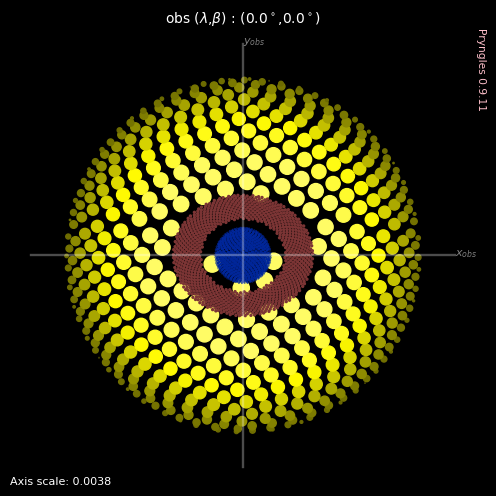

In [32]:
# Integrate at time t=0 (primary transit)
system.integrate_perspective(0)

# Visualize the system
system.sg.plot2d()

---

## 4. Temperature models

We define temperature-distribution models for the planet, required to compute thermal emission.

### 4.1 Planet temperature model: Zhang & Showman

This model parameterizes heat redistribution in strongly irradiated planets, with a hot spot offset from the substellar point due to atmospheric circulation.

In [33]:
# Planet temperature model
T_planet_model = {
    "type": "Zhang-Showman",
    "params": {
        "T_night": system_params['T_night'],      # Nightside hemisphere temperature [K]
        "Delta_T": system_params['Delta_T'],      # Day-night temperature contrast [K]
        "xi_ratio": system_params['xi']           # Hot-spot offset parameter
    }
}

# Apply the temperature model to the planet
planet.set_temperature_model(T_planet_model)

print("Zhang & Showman temperature model applied to the planet:")
print(f"  T_night = {system_params['T_night']} K")
print(f"  T_day = {system_params['T_night'] + system_params['Delta_T']} K")
print(f"  Hot-spot offset: ξ = {system_params['xi']}")

Zhang & Showman temperature model applied to the planet:
  T_night = 1200 K
  T_day = 2000 K
  Hot-spot offset: ξ = 0.3


---

## 5. Detector configuration

We define the properties of the telescope and detector that will observe the system.

In [34]:
# Detector / telescope properties
DETECTOR_PROPERTIES = {
    # Spectral band
    'wavelength_min': system_params['lambda_min'],  # [m]
    'wavelength_max': system_params['lambda_max'],  # [m]

    # Telescope aperture
    'apperture': 0.5,                               # [m] (50 cm diameter)

    # Detector quantum efficiency
    'quantum_eff': 0.9,                             # 90% efficiency

    # Cadence (exposure time)
    't_cadence': 15 * 60,                           # 15 minutes [s]

    # Distance to the system
    'distance': 100 * pr.Consts.pc                  # 100 parsecs [m]
}

print("Detector configuration:")
print(f"  Band: {DETECTOR_PROPERTIES['wavelength_min']*1e9:.0f} - {DETECTOR_PROPERTIES['wavelength_max']*1e9:.0f} nm")
print(f"  Aperture: {DETECTOR_PROPERTIES['apperture']*100:.0f} cm")
print(f"  Quantum efficiency: {DETECTOR_PROPERTIES['quantum_eff']*100:.0f}%")
print(f"  Cadence: {DETECTOR_PROPERTIES['t_cadence']/60:.0f} minutes")
print(f"  Distance to system: {DETECTOR_PROPERTIES['distance']/pr.Consts.pc:.1f} pc")

Detector configuration:
  Band: 1100 - 1700 nm
  Aperture: 50 cm
  Quantum efficiency: 90%
  Cadence: 15 minutes
  Distance to system: 100.0 pc


---

## 6. Computing the full light curve

We compute the light curve over a full orbital period.

In [35]:
# Number of time samples
n_times = 150

# Integration times: one orbital period centered on transit
times_days = np.linspace(
    -system_params['period'] / 2,
    system_params['period'] / 2,
    n_times
)  # [days]

# Convert to system time units
times_system = times_days * pr.Consts.day / system.ut  # [system time units]

print(f"  Number of points: {n_times}")
print(f"  Range: {times_days[0]:.3f} to {times_days[-1]:.3f} days")
print(f"  Time step: {(times_days[1] - times_days[0]) * 24 * 60:.2f} minutes")

  Number of points: 150
  Range: -0.407 to 0.407 days
  Time step: 7.86 minutes


### 6.1 Computing the light curve with all effects

We use `pryngles`'s `compute_lightcurve` method to compute, simultaneously:
- **transit**: attenuation due to occultation of the stellar disk
- **emission**: thermal flux from the planet
- **polarization**: fraction of reflected/scattered and polarized light from rings and atmospheres

The `system.lightcurve` attribute contains the full result of the light-curve computation for a given time grid and, optionally, a synthetic instrumental signal. It also includes the per-effect models and the contributions from each body.

---

#### Dictionary items

- **`times`** (`np.ndarray`)
  1D array of times where the light curve was evaluated.
  Values are expressed in the internal units of the dynamical system.

- **`flux`** (`np.ndarray`)
  Total normalized flux of the system at each time.
  Includes the combined contribution of all selected physical effects (transit, emission, polarization, etc.).
  The unperturbed stellar flux is normalized to 1.

- **`model`** (`pandas.DataFrame`)
  Detailed light-curve model with `MultiIndex` columns:
  - Level 0: body name (`body`)
  - Level 1: physical effect (`effect`)
  Contains the individual contributions of each body and each physical effect before they are combined into the total flux.
  Models are defined from the requested effects `["reflection", "transit", "emission", "polarization"]`.

- **`effects`** (`list`)
  Tuple with the names of the physical effects included in the light-curve computation.
  Example: `["transit", "emission", "polarization"]`.

- **`bodies`** (`list`)
  List of body names considered in the light-curve computation.
  By default, it includes all non-stellar bodies in the system.

- **`observer`** (`dict`)
  Dictionary describing the observer geometry used in the computation:
  - **`n_obs`** (`np.array`): unit vector defining the observer direction in the model reference frame.
  - **`direction`** (`np.array`): observer direction expressed in angular coordinates (degrees), typically ecliptic longitude and latitude.

- **`bandwidth`** (`tuple`)
  Spectral range `(λ_min, λ_max)` in meters used to integrate thermal emission.
  Only relevant if emission is included in `effects`.

- **`signal`** (`dict`, optional)
  Present only if instrumental signal simulation was requested:
  - **`times`** (`np.array`): instrument observation times in seconds.
  - **`signal_flux`** (`np.array`): simulated observed total flux, including instrumental noise.
  - **`signal_error`** (`np.array`): uncertainty associated with each simulated flux point.

**Note:** You will see the compute time. Keep in mind we are computing multiple effects and generating a synthetic signal. For efficiency, it is recommended to compute one effect at a time when iterating.

In [36]:
print("Computing full light curve...\n")

# Compute the light curve including the three effects

# Transit and signal
system.compute_lightcurve(
    times=times_system,
    effects=['transit'],
    signal=DETECTOR_PROPERTIES,
)

transit_flux = system.lightcurve['transit']

print(f"  Transit - maximum depth: {(-transit_flux.sum(axis=1).min()):.3f}")

# Emission
system.compute_lightcurve(
    times=times_system,
    bandwidth=(system_params['lambda_min'], system_params['lambda_max']),
    effects=['emission'],
)

emission_flux = system.lightcurve['emission']

print(f"  Thermal emission - max flux: {emission_flux.sum(axis=1).max() * 1e6:.2e} ppm")

# Polarization
system.compute_lightcurve(
    times=times_system,
    effects=['polarization'],
)

polarized_flux = system.lightcurve['scattering']
polarized_degree = system.lightcurve['polarization']

print(f"  Polarization - max degree: {polarized_degree.sum(axis=1).max():.4f}%")

# TOTAL FLUX
total_flux = 1 + transit_flux.sum(axis=1) + emission_flux.sum(axis=1) + polarized_flux.sum(axis=1)

print("\n✓ Light curve computed successfully.")
print("\nResults stored in system.lightcurve\n")
print(f"Available keys: {list(system.lightcurve.keys())}")

Computing full light curve...



Computing Lightcurve : 100%|██████████| 150/150 [00:28<00:00,  5.20it/s]


  Transit - maximum depth: 0.137


Computing Lightcurve : 100%|██████████| 150/150 [00:30<00:00,  4.87it/s]


  Thermal emission - max flux: 5.49e+02 ppm


Computing Lightcurve : 100%|██████████| 150/150 [02:23<00:00,  1.04it/s]

  Polarization - max degree: 0.4071%

✓ Light curve computed successfully.

Results stored in system.lightcurve

Available keys: ['times', 'total_flux', 'effects', 'bodies', 'observer', 'bandwidth', 'polarization', 'scattering']


### 6.2 Synthetic signal generation

We previously created the system detector in the `system.detector` attribute. Now, based on the total flux, we generate a synthetic observational signal using `Detector.generate_signal()`. This method returns the following detector outputs:

- **`times`** (`np.ndarray`)
  1D array of times where the light-curve signal was evaluated.
  Values are expressed in seconds.

- **`signal_flux`** (`np.ndarray`)
  Simulated observed (normalized) total flux at each time.

- **`signal_error`** (`np.ndarray`)
  Stochastic noise realization / uncertainty associated with each simulated flux point.

In [37]:
signal_times, signal_flux, signal_error = system.detector.generate_signal(times_system*system.ut, total_flux)

---

## 7. Results visualization

### 7.1 Transit light curve

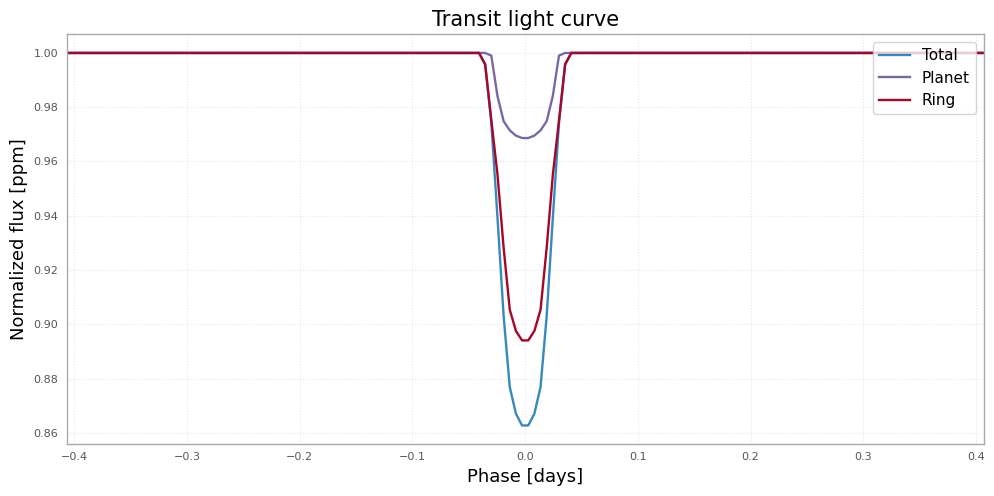

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

# Transit depth
ax.plot(times_days, 1 + transit_flux.sum(axis=1), label='Total')

ax.plot(times_days, 1 + transit_flux['Planet'], label='Planet')
ax.plot(times_days, 1 + transit_flux['Ring'], label='Ring')

ax.set_xlabel('Phase [days]', fontsize=13)
ax.set_ylabel('Normalized flux [ppm]', fontsize=13)
ax.set_title('Transit light curve', fontsize=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(times_days[0], times_days[-1])

plt.tight_layout()
plt.show()

### 7.2 Thermal emission light curve

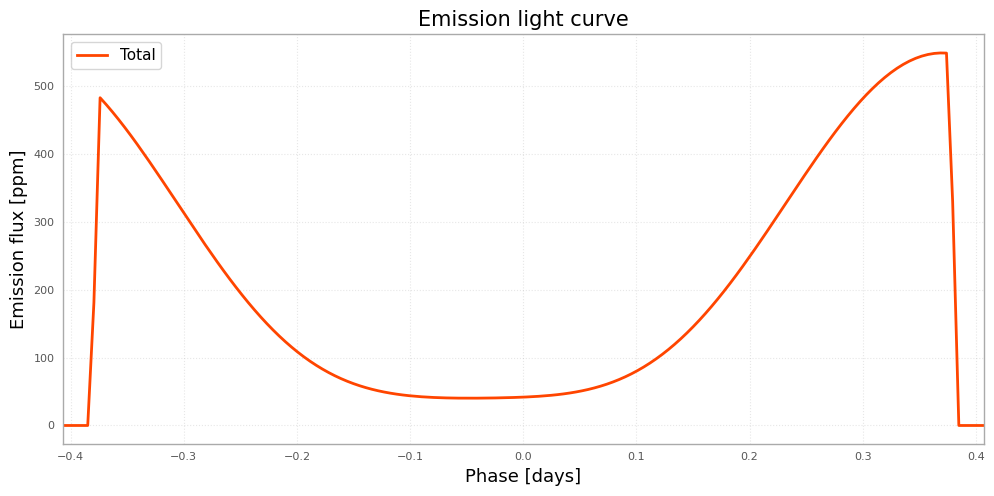

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_days, emission_flux.sum(axis=1) * 1e6, color='orangered', linewidth=2, label='Total')

ax.set_xlabel('Phase [days]', fontsize=13)
ax.set_ylabel('Emission flux [ppm]', fontsize=13)
ax.set_title('Emission light curve', fontsize=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(times_days[0], times_days[-1])

plt.tight_layout()
plt.show()

### 7.3 Polarization light curve

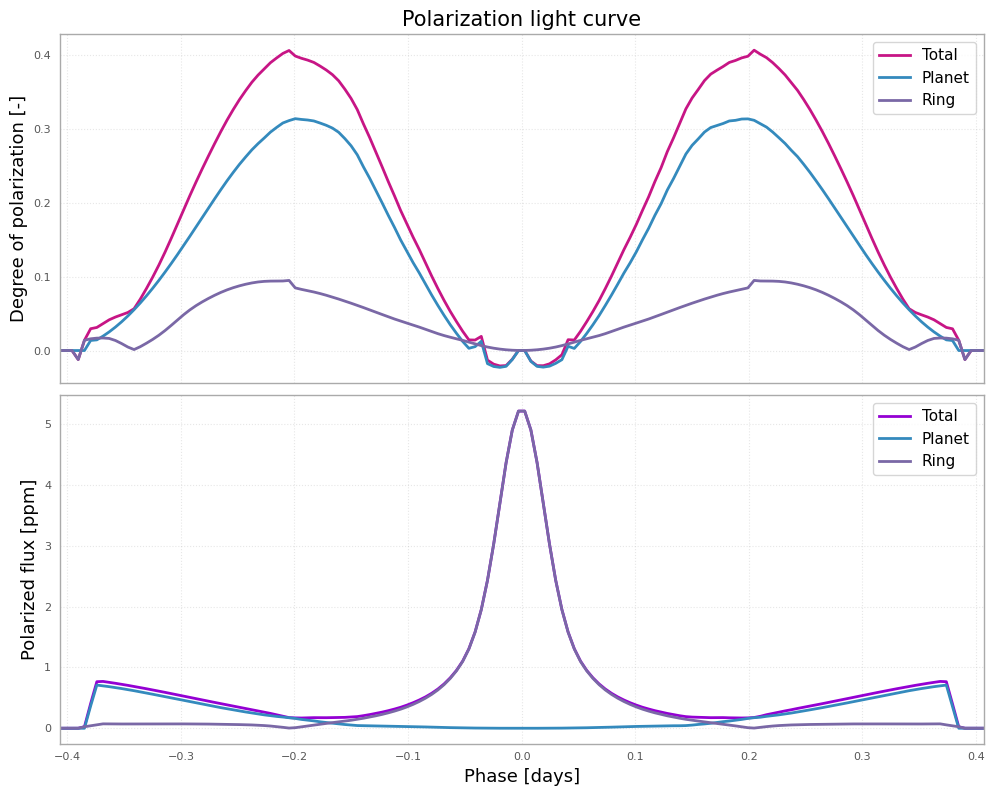

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top panel: degree of polarization
ax1.plot(times_days, polarized_degree.sum(axis=1), color='mediumvioletred', linewidth=2, label='Total')

ax1.plot(times_days, polarized_degree['Planet'], linewidth=2, label='Planet')
ax1.plot(times_days, polarized_degree['Ring'], linewidth=2, label='Ring')

ax1.set_ylabel('Degree of polarization [-]', fontsize=13)
ax1.set_title('Polarization light curve', fontsize=15)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle=':')

# Bottom panel: polarized flux
ax2.plot(times_days, polarized_flux.sum(axis=1) * 1e6, color='darkviolet', linewidth=2, label='Total')

ax2.plot(times_days, polarized_flux['Planet'] * 1e6, linewidth=2, label='Planet')
ax2.plot(times_days, polarized_flux['Ring'] * 1e6, linewidth=2, label='Ring')

ax2.set_xlabel('Phase [days]', fontsize=13)
ax2.set_ylabel('Polarized flux [ppm]', fontsize=13)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.set_xlim(times_days[0], times_days[-1])

plt.tight_layout()
plt.show()

### 7.4 Full light curve and observational signal

Integrated visualization of the three photometric effects together with the synthetic light-curve signal generation.

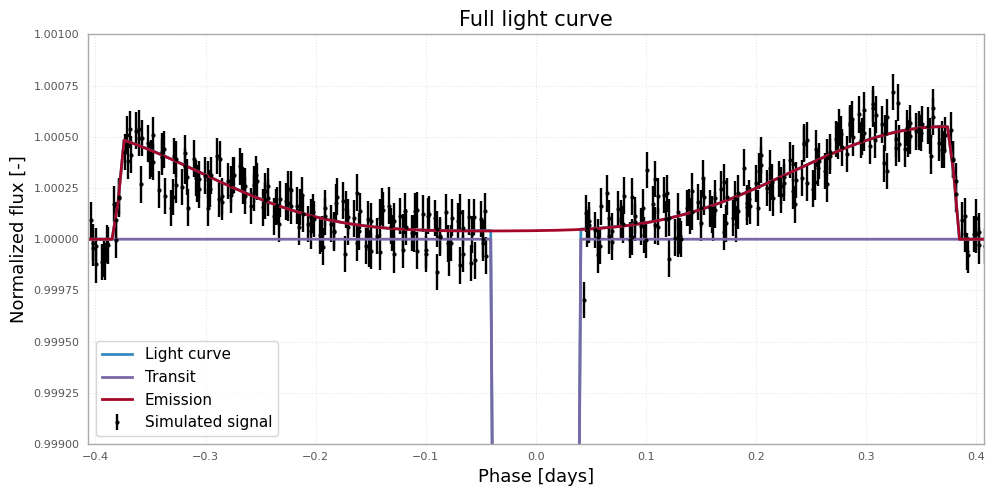

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

# Signal
ax.errorbar(
    signal_times / pr.Consts.days,
    signal_flux,
    yerr=signal_error,
    markersize=2,
    fmt='o',
    label='Simulated signal',
    color='black',
    alpha=1,
)

ax.plot(times_days, total_flux, color='C0', linewidth=2, label='Light curve')
ax.plot(times_days, 1 + transit_flux.sum(axis=1), color='C1', linewidth=2, label='Transit')
ax.plot(times_days, 1 + emission_flux.sum(axis=1), color='C2', linewidth=2, label='Emission')

ax.set_xlabel('Phase [days]', fontsize=13)
ax.set_ylabel('Normalized flux [-]', fontsize=13)
ax.set_title('Full light curve', fontsize=15)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(times_days[0], times_days[-1])
ax.set_ylim(0.999, 1.001)

plt.tight_layout()
plt.show()

---

## Summary

This notebook demonstrated how to use `pryngles` to simultaneously model:

1. **Transit light curves** of ringed planets
2. **Thermal emission**, using realistic planetary temperature distributions (ring-related thermal effects are not yet included)
3. **Polarimetric signals** of reflected and scattered light from atmospheric surfaces and rings

### References and documentation

- **Pryngles repository**: [https://github.com/seap-udea/pryngles](https://github.com/seap-udea/pryngles)
- **Pryngles API**: [ReadTheDocs](https://pryngles.readthedocs.io/en/latest/)

---

**Author**: Sebastián Numpaque & Jorge I. Zuluaga 

**Version**: pryngles 1.0.0

**Date**: 2026-05-06